# Predicting EV Charging Demand Using Machine Learning

## Research Questions

1. To what extent can machine learning models accurately predict electric vehicle charging demand based on charging session characteristics and temporal features?

2. How does the inclusion of temporal features, such as time of day and day of week, affect model performance?

## Methodology

This notebook is structured as follows:

1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Feature Engineering
4. Train/Test Split
5. Experiment 1: Models with temporal features
6. Experiment 2: Models without temporal features
7. Hyperparameter tuning for both experiments
8. Final comparison of results

Three machine learning models are evaluated:

- Linear Regression
- Random Forest
- XGBoost

Model performance is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

## Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/SYNTHETIC_EV_DATA.csv')

# Display the first few rows
data.head()

,connectionTime_decimal,chargingDuration,kWhDelivered,dayIndicator
0,15.332910,2.301191,11.469551,1
1,16.811495,4.941774,3.611695,1
2,21.151696,3.567173,14.455706,1
3,14.988554,3.089371,5.985330,1
4,15.078276,0.145047,1.274458,1


## Dataset Overview

In [ ]:
print("Dataset Shape:", data.shape)
data.info()

Dataset Shape: (1965239, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1965239 entries, 0 to 1965238
Data columns (total 4 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   connectionTime_decimal  float64
 1   chargingDuration        float64
 2   kWhDelivered            float64
 3   dayIndicator            int64  
dtypes: float64(3), int64(1)
memory usage: 60.0 MB


## Summary Statistics

In [ ]:
data.describe()

,connectionTime_decimal,chargingDuration,kWhDelivered,dayIndicator
count,1.965239e+06,1.965239e+06,1.965239e+06,1.965239e+06
mean,1.448631e+01,3.800781e+00,9.437424e+00,1.480029e+04
std,6.427672e+00,3.387723e+00,5.700660e+00,8.531910e+03
min,7.236954e-06,1.384907e-05,3.700269e-04,1.000000e+00
25%,1.424779e+01,1.443232e+00,4.868768e+00,7.424000e+03
50%,1.616805e+01,2.547029e+00,9.174554e+00,1.479300e+04
75%,1.804136e+01,5.436214e+00,1.356673e+01,2.219800e+04
max,2.400000e+01,3.941106e+01,6.253769e+01,2.960000e+04


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure of the dataset, examine distributions of important variables, and identify patterns related to EV charging behaviour.

In [ ]:
data.isnull().sum()

,0
connectionTime_decimal,0
chargingDuration,0
kWhDelivered,0
dayIndicator,0


## Distribution of Energy Delivered

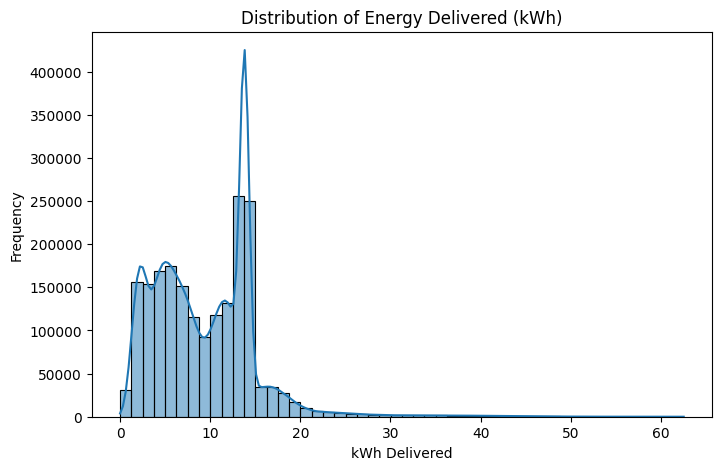

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data['kWhDelivered'], bins=50, kde=True)
plt.title("Distribution of Energy Delivered (kWh)")
plt.xlabel("kWh Delivered")
plt.ylabel("Frequency")
plt.show()

## Distribution of Charging Duration

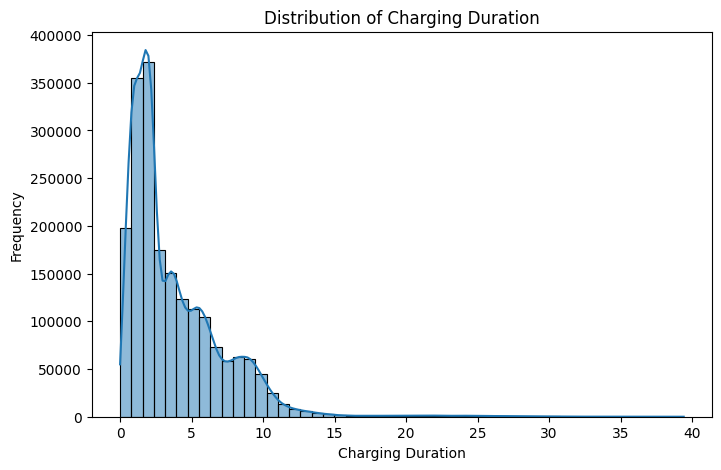

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data['chargingDuration'], bins=50, kde=True)
plt.title("Distribution of Charging Duration")
plt.xlabel("Charging Duration")
plt.ylabel("Frequency")
plt.show()

## Connection Time vs Energy Delivered

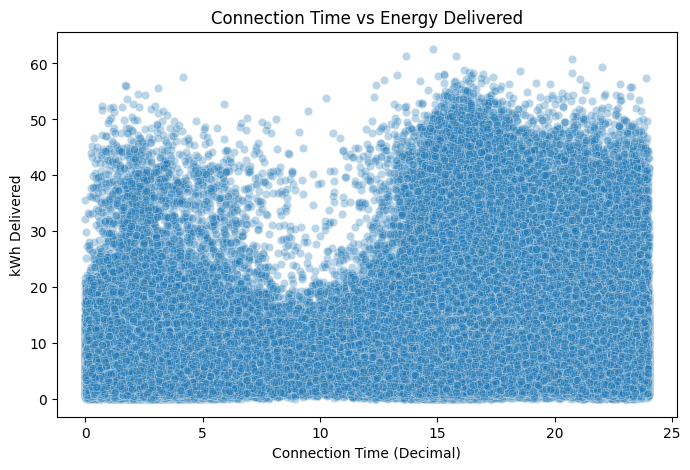

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=data['connectionTime_decimal'], y=data['kWhDelivered'], alpha=0.3)
plt.title("Connection Time vs Energy Delivered")
plt.xlabel("Connection Time (Decimal)")
plt.ylabel("kWh Delivered")
plt.show()

## Correlation Matrix

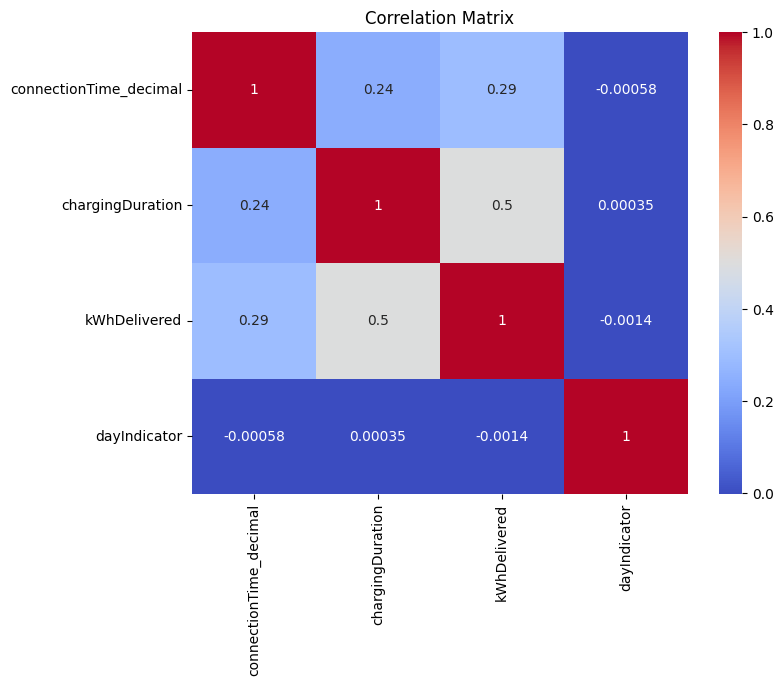

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Data Preprocessing

The dataset is checked for missing values and prepared for feature engineering and modelling.

In [ ]:
data.isnull().sum()

,0
connectionTime_decimal,0
chargingDuration,0
kWhDelivered,0
dayIndicator,0


# Feature Engineering (Temporal Features)

Temporal features are created to help the models capture time-based charging behaviour.

The following temporal features are added:

- `hour`: hour of connection
- `weekday`: weekday or weekend indicator
- `peakHour`: whether the charging session occurred during evening peak hours

In [ ]:
data['hour'] = data['connectionTime_decimal'].astype(int)
data['weekday'] = (data['dayIndicator'] % 7 < 5).astype(int)
data['peakHour'] = ((data['hour'] >= 17) & (data['hour'] <= 21)).astype(int)

data.head()

,connectionTime_decimal,chargingDuration,kWhDelivered,dayIndicator,hour,weekday,peakHour
0,15.332910,2.301191,11.469551,1,15,1,0
1,16.811495,4.941774,3.611695,1,16,1,0
2,21.151696,3.567173,14.455706,1,21,1,1
3,14.988554,3.089371,5.985330,1,14,1,0
4,15.078276,0.145047,1.274458,1,15,1,0


## Sampling the Dataset

As the dataset is very large, a sample is used to reduce computational cost while maintaining a representative subset for modelling.

In [ ]:
data_sample = data.sample(200000, random_state=42)
print("Sampled Dataset Shape:", data_sample.shape)

Sampled Dataset Shape: (200000, 7)


## Define Feature Sets

Two feature sets are created:

### With Temporal Features
- connectionTime_decimal
- chargingDuration
- hour
- weekday
- peakHour

### Without Temporal Features
- connectionTime_decimal
- chargingDuration

In [ ]:
X_temporal = data_sample[['connectionTime_decimal',
                          'chargingDuration',
                          'hour',
                          'weekday',
                          'peakHour']]

X_basic = data_sample[['connectionTime_decimal',
                       'chargingDuration']]

y = data_sample['kWhDelivered']

# Train/Test Split

The data is split into training and testing sets to evaluate how well the models generalise to unseen data.

In [ ]:
Xt_train, Xt_test, y_train, y_test = train_test_split(
    X_temporal, y, test_size=0.2, random_state=42
)

Xb_train, Xb_test, _, _ = train_test_split(
    X_basic, y, test_size=0.2, random_state=42
)

print("Temporal Train Shape:", Xt_train.shape)
print("Temporal Test Shape:", Xt_test.shape)
print("Basic Train Shape:", Xb_train.shape)
print("Basic Test Shape:", Xb_test.shape)

Temporal Train Shape: (160000, 5)
Temporal Test Shape: (40000, 5)
Basic Train Shape: (160000, 2)
Basic Test Shape: (40000, 2)


# Experiment 1: WITH Temporal Features

In this experiment, the models are trained using charging session characteristics together with temporal features.

## Linear Regression Baseline (With Temporal Features)

In [ ]:
lr_temp = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lr_temp.fit(Xt_train, y_train)
lr_temp_pred = lr_temp.predict(Xt_test)

lr_temp_mae = mean_absolute_error(y_test, lr_temp_pred)
lr_temp_rmse = np.sqrt(mean_squared_error(y_test, lr_temp_pred))
lr_temp_r2 = r2_score(y_test, lr_temp_pred)

print("Linear Regression - With Temporal Features")
print("MAE:", lr_temp_mae)
print("RMSE:", lr_temp_rmse)
print("R2:", lr_temp_r2)

Linear Regression - With Temporal Features
MAE: 3.4047346049413973
RMSE: 4.801745406020514
R2: 0.2838807885022664


## Random Forest Baseline (With Temporal Features)

In [ ]:
rf_temp = RandomForestRegressor(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

rf_temp.fit(Xt_train, y_train)
rf_temp_pred = rf_temp.predict(Xt_test)

rf_temp_mae = mean_absolute_error(y_test, rf_temp_pred)
rf_temp_rmse = np.sqrt(mean_squared_error(y_test, rf_temp_pred))
rf_temp_r2 = r2_score(y_test, rf_temp_pred)

print("Random Forest - With Temporal Features")
print("MAE:", rf_temp_mae)
print("RMSE:", rf_temp_rmse)
print("R2:", rf_temp_r2)

Random Forest - With Temporal Features
MAE: 3.22279128650106
RMSE: 4.707002017556934
R2: 0.311861534582099


## XGBoost Baseline (With Temporal Features)

In [ ]:
xgb_temp = XGBRegressor(
    n_estimators=30,
    objective='reg:squarederror',
    random_state=42
)

xgb_temp.fit(Xt_train, y_train)
xgb_temp_pred = xgb_temp.predict(Xt_test)

xgb_temp_mae = mean_absolute_error(y_test, xgb_temp_pred)
xgb_temp_rmse = np.sqrt(mean_squared_error(y_test, xgb_temp_pred))
xgb_temp_r2 = r2_score(y_test, xgb_temp_pred)

print("XGBoost - With Temporal Features")
print("MAE:", xgb_temp_mae)
print("RMSE:", xgb_temp_rmse)
print("R2:", xgb_temp_r2)

XGBoost - With Temporal Features
MAE: 2.8813665941910536
RMSE: 4.3619419624290146
R2: 0.40905531447579024


# Experiment 2: WITHOUT Temporal Features

In this experiment, the models are trained only using charging session characteristics without any temporal information.

## Linear Regression Baseline (Without Temporal Features)

In [ ]:
lr_basic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lr_basic.fit(Xb_train, y_train)
lr_basic_pred = lr_basic.predict(Xb_test)

lr_basic_mae = mean_absolute_error(y_test, lr_basic_pred)
lr_basic_rmse = np.sqrt(mean_squared_error(y_test, lr_basic_pred))
lr_basic_r2 = r2_score(y_test, lr_basic_pred)

print("Linear Regression - Without Temporal Features")
print("MAE:", lr_basic_mae)
print("RMSE:", lr_basic_rmse)
print("R2:", lr_basic_r2)

Linear Regression - Without Temporal Features
MAE: 3.4051985056484844
RMSE: 4.805870158703536
R2: 0.28264995135080473


## Random Forest Baseline (Without Temporal Features)

In [ ]:
rf_basic = RandomForestRegressor(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

rf_basic.fit(Xb_train, y_train)
rf_basic_pred = rf_basic.predict(Xb_test)

rf_basic_mae = mean_absolute_error(y_test, rf_basic_pred)
rf_basic_rmse = np.sqrt(mean_squared_error(y_test, rf_basic_pred))
rf_basic_r2 = r2_score(y_test, rf_basic_pred)

print("Random Forest - Without Temporal Features")
print("MAE:", rf_basic_mae)
print("RMSE:", rf_basic_rmse)
print("R2:", rf_basic_r2)

Random Forest - Without Temporal Features
MAE: 3.2413917471806757
RMSE: 4.729210252962203
R2: 0.3053527661598163


## XGBoost Baseline (Without Temporal Features)

In [ ]:
xgb_basic = XGBRegressor(
    n_estimators=30,
    objective='reg:squarederror',
    random_state=42
)

xgb_basic.fit(Xb_train, y_train)
xgb_basic_pred = xgb_basic.predict(Xb_test)

xgb_basic_mae = mean_absolute_error(y_test, xgb_basic_pred)
xgb_basic_rmse = np.sqrt(mean_squared_error(y_test, xgb_basic_pred))
xgb_basic_r2 = r2_score(y_test, xgb_basic_pred)

print("XGBoost - Without Temporal Features")
print("MAE:", xgb_basic_mae)
print("RMSE:", xgb_basic_rmse)
print("R2:", xgb_basic_r2)

XGBoost - Without Temporal Features
MAE: 2.8829126062788033
RMSE: 4.365642252917614
R2: 0.4080522775227081


# Tuning WITH Temporal Features

Hyperparameter tuning is applied separately to each model using the feature set that includes temporal variables.

## Linear Regression Tuning (With Temporal Features)

In [ ]:
lr_params = {
    'model__alpha': [0.01, 0.1, 1, 10]
}

lr_grid_temp = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ]),
    lr_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

lr_grid_temp.fit(Xt_train, y_train)
lr_temp_tuned_pred = lr_grid_temp.predict(Xt_test)

lr_temp_tuned_mae = mean_absolute_error(y_test, lr_temp_tuned_pred)
lr_temp_tuned_rmse = np.sqrt(mean_squared_error(y_test, lr_temp_tuned_pred))
lr_temp_tuned_r2 = r2_score(y_test, lr_temp_tuned_pred)

print("Tuned Linear Regression - With Temporal Features")
print("Best Parameters:", lr_grid_temp.best_params_)
print("MAE:", lr_temp_tuned_mae)
print("RMSE:", lr_temp_tuned_rmse)
print("R2:", lr_temp_tuned_r2)

Tuned Linear Regression - With Temporal Features
Best Parameters: {'model__alpha': 10}
MAE: 3.40475689395578
RMSE: 4.801756241641065
R2: 0.28387755650883706


## Random Forest Tuning

In [ ]:
rf_params = {
    'n_estimators': [30, 50],
    'max_depth': [8, 12],
    'min_samples_split': [2, 5]
}

rf_grid_temp = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

rf_grid_temp.fit(Xt_train, y_train)
rf_temp_tuned_pred = rf_grid_temp.predict(Xt_test)

rf_temp_tuned_mae = mean_absolute_error(y_test, rf_temp_tuned_pred)
rf_temp_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_temp_tuned_pred))
rf_temp_tuned_r2 = r2_score(y_test, rf_temp_tuned_pred)

print("Tuned Random Forest - With Temporal Features")
print("Best Parameters:", rf_grid_temp.best_params_)
print("MAE:", rf_temp_tuned_mae)
print("RMSE:", rf_temp_tuned_rmse)
print("R2:", rf_temp_tuned_r2)

Tuned Random Forest - With Temporal Features
Best Parameters: {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 50}
MAE: 2.87566762820875
RMSE: 4.357805186125524
R2: 0.4101756626077512


## XGBoost Tuning (With Temporal Features)

In [ ]:
xgb_params = {
    'n_estimators': [30, 50],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1]
}

xgb_grid_temp = GridSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42),
    xgb_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

xgb_grid_temp.fit(Xt_train, y_train)
xgb_temp_tuned_pred = xgb_grid_temp.predict(Xt_test)

xgb_temp_tuned_mae = mean_absolute_error(y_test, xgb_temp_tuned_pred)
xgb_temp_tuned_rmse = np.sqrt(mean_squared_error(y_test, xgb_temp_tuned_pred))
xgb_temp_tuned_r2 = r2_score(y_test, xgb_temp_tuned_pred)

print("Tuned XGBoost - With Temporal Features")
print("Best Parameters:", xgb_grid_temp.best_params_)
print("MAE:", xgb_temp_tuned_mae)
print("RMSE:", xgb_temp_tuned_rmse)
print("R2:", xgb_temp_tuned_r2)

Tuned XGBoost - With Temporal Features
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 50, 'subsample': 1}
MAE: 2.8739663559658477
RMSE: 4.354812651916571
R2: 0.4109854571667051


# Tuning WITHOUT Temporal Features

Hyperparameter tuning is also applied separately to the models using only the non-temporal charging session features.

## Linear Regression Tuning (Without Temporal Features)

In [ ]:
lr_grid_basic = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ]),
    lr_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

lr_grid_basic.fit(Xb_train, y_train)
lr_basic_tuned_pred = lr_grid_basic.predict(Xb_test)

lr_basic_tuned_mae = mean_absolute_error(y_test, lr_basic_tuned_pred)
lr_basic_tuned_rmse = np.sqrt(mean_squared_error(y_test, lr_basic_tuned_pred))
lr_basic_tuned_r2 = r2_score(y_test, lr_basic_tuned_pred)

print("Tuned Linear Regression - Without Temporal Features")
print("Best Parameters:", lr_grid_basic.best_params_)
print("MAE:", lr_basic_tuned_mae)
print("RMSE:", lr_basic_tuned_rmse)
print("R2:", lr_basic_tuned_r2)

Tuned Linear Regression - Without Temporal Features
Best Parameters: {'model__alpha': 10}
MAE: 3.405219254194531
RMSE: 4.805871390324474
R2: 0.28264958367401627


## Random Forest Tuning (Without Temporal Features)

In [ ]:
rf_grid_basic = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

rf_grid_basic.fit(Xb_train, y_train)
rf_basic_tuned_pred = rf_grid_basic.predict(Xb_test)

rf_basic_tuned_mae = mean_absolute_error(y_test, rf_basic_tuned_pred)
rf_basic_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_basic_tuned_pred))
rf_basic_tuned_r2 = r2_score(y_test, rf_basic_tuned_pred)

print("Tuned Random Forest - Without Temporal Features")
print("Best Parameters:", rf_grid_basic.best_params_)
print("MAE:", rf_basic_tuned_mae)
print("RMSE:", rf_basic_tuned_rmse)
print("R2:", rf_basic_tuned_r2)

Tuned Random Forest - Without Temporal Features
Best Parameters: {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 50}
MAE: 2.8761101599145613
RMSE: 4.357736416062615
R2: 0.4101942783718808


## XGBoost Tuning (Without Temporal Features)

In [ ]:
xgb_grid_basic = GridSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42),
    xgb_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

xgb_grid_basic.fit(Xb_train, y_train)
xgb_basic_tuned_pred = xgb_grid_basic.predict(Xb_test)

xgb_basic_tuned_mae = mean_absolute_error(y_test, xgb_basic_tuned_pred)
xgb_basic_tuned_rmse = np.sqrt(mean_squared_error(y_test, xgb_basic_tuned_pred))
xgb_basic_tuned_r2 = r2_score(y_test, xgb_basic_tuned_pred)

print("Tuned XGBoost - Without Temporal Features")
print("Best Parameters:", xgb_grid_basic.best_params_)
print("MAE:", xgb_basic_tuned_mae)
print("RMSE:", xgb_basic_tuned_rmse)
print("R2:", xgb_basic_tuned_r2)

Tuned XGBoost - Without Temporal Features
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 50, 'subsample': 0.8}
MAE: 2.873716905311655
RMSE: 4.3552029593551405
R2: 0.410879869588863


# Final Comparison Table

This section compares:

- baseline vs tuned performance
- temporal vs non-temporal performance
- all three models across MAE, RMSE, and R²

In [ ]:
final_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],

    "MAE_Temporal_Baseline": [lr_temp_mae, rf_temp_mae, xgb_temp_mae],
    "RMSE_Temporal_Baseline": [lr_temp_rmse, rf_temp_rmse, xgb_temp_rmse],
    "R2_Temporal_Baseline": [lr_temp_r2, rf_temp_r2, xgb_temp_r2],

    "MAE_Temporal_Tuned": [lr_temp_tuned_mae, rf_temp_tuned_mae, xgb_temp_tuned_mae],
    "RMSE_Temporal_Tuned": [lr_temp_tuned_rmse, rf_temp_tuned_rmse, xgb_temp_tuned_rmse],
    "R2_Temporal_Tuned": [lr_temp_tuned_r2, rf_temp_tuned_r2, xgb_temp_tuned_r2],

    "MAE_NoTemporal_Baseline": [lr_basic_mae, rf_basic_mae, xgb_basic_mae],
    "RMSE_NoTemporal_Baseline": [lr_basic_rmse, rf_basic_rmse, xgb_basic_rmse],
    "R2_NoTemporal_Baseline": [lr_basic_r2, rf_basic_r2, xgb_basic_r2],

    "MAE_NoTemporal_Tuned": [lr_basic_tuned_mae, rf_basic_tuned_mae, xgb_basic_tuned_mae],
    "RMSE_NoTemporal_Tuned": [lr_basic_tuned_rmse, rf_basic_tuned_rmse, xgb_basic_tuned_rmse],
    "R2_NoTemporal_Tuned": [lr_basic_tuned_r2, rf_basic_tuned_r2, xgb_basic_tuned_r2]
})

final_comparison

,Model,MAE_Temporal_Baseline,RMSE_Temporal_Baseline,R2_Temporal_Baseline,MAE_Temporal_Tuned,RMSE_Temporal_Tuned,R2_Temporal_Tuned,MAE_NoTemporal_Baseline,RMSE_NoTemporal_Baseline,R2_NoTemporal_Baseline,MAE_NoTemporal_Tuned,RMSE_NoTemporal_Tuned,R2_NoTemporal_Tuned
0,Linear Regression,3.404735,4.801745,0.283881,3.404757,4.801756,0.283878,3.405199,4.805870,0.282650,3.405219,4.805871,0.282650
1,Random Forest,3.222791,4.707002,0.311862,2.875668,4.357805,0.410176,3.241392,4.729210,0.305353,2.876110,4.357736,0.410194
2,XGBoost,2.881367,4.361942,0.409055,2.873966,4.354813,0.410985,2.882913,4.365642,0.408052,2.873717,4.355203,0.410880


## Performance Improvement After Tuning

In [ ]:
improvement_table = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],

    "Temporal_R2_Improvement": [
        lr_temp_tuned_r2 - lr_temp_r2,
        rf_temp_tuned_r2 - rf_temp_r2,
        xgb_temp_tuned_r2 - xgb_temp_r2
    ],

    "NoTemporal_R2_Improvement": [
        lr_basic_tuned_r2 - lr_basic_r2,
        rf_basic_tuned_r2 - rf_basic_r2,
        xgb_basic_tuned_r2 - xgb_basic_r2
    ],

    "Temporal_Feature_Impact_Baseline": [
        lr_temp_r2 - lr_basic_r2,
        rf_temp_r2 - rf_basic_r2,
        xgb_temp_r2 - xgb_basic_r2
    ],

    "Temporal_Feature_Impact_Tuned": [
        lr_temp_tuned_r2 - lr_basic_tuned_r2,
        rf_temp_tuned_r2 - rf_basic_tuned_r2,
        xgb_temp_tuned_r2 - xgb_basic_tuned_r2
    ]
})

improvement_table

,Model,Temporal_R2_Improvement,NoTemporal_R2_Improvement,Temporal_Feature_Impact_Baseline,Temporal_Feature_Impact_Tuned
0,Linear Regression,-0.000003,-3.676768e-07,0.001231,0.001228
1,Random Forest,0.098314,1.048415e-01,0.006509,-0.000019
2,XGBoost,0.001930,2.827592e-03,0.001003,0.000106


## Visual Comparison of Tuned R² Scores

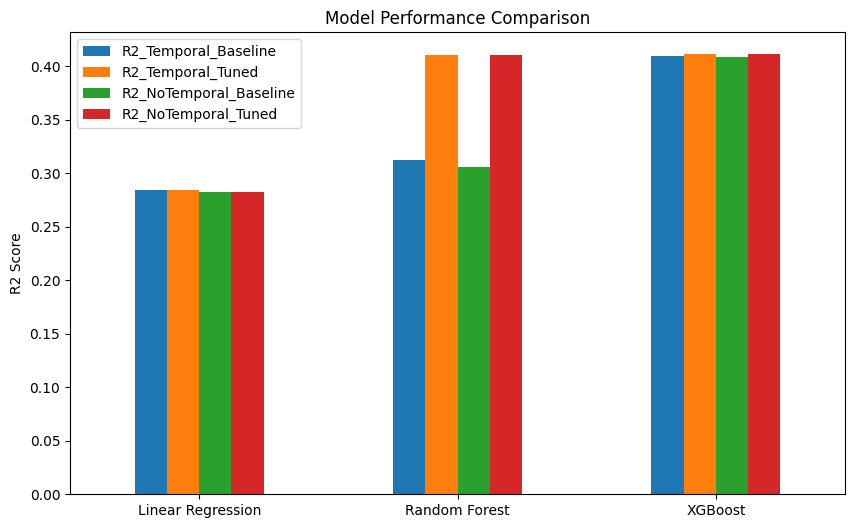

In [ ]:
comparison = final_comparison[[
"R2_Temporal_Baseline",
"R2_Temporal_Tuned",
"R2_NoTemporal_Baseline",
"R2_NoTemporal_Tuned"
]]

comparison.index = ["Linear Regression","Random Forest","XGBoost"]

comparison.plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")

plt.ylabel("R2 Score")

plt.xticks(rotation=0)

plt.show()